# SnapTrip Tourism Classifier - MobileNetV4 Medium

Notebook ini melatih classifier gambar untuk empat kategori canonical SnapTrip: `pantai`, `gunung`, `air_terjun`, dan `wisata_tradisional`.

Model yang digunakan adalah MobileNetV4 Medium melalui `timm`, dengan output tetap mengikuti kebutuhan PRD: label canonical dan confidence score.

In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import timm

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
EPOCHS = 30
FREEZE_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 7
MIN_DELTA = 1e-4
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MODEL_NAME = "mobilenetv4_conv_medium.e500_r224_in1k"

CLASSES = ["pantai", "gunung", "air_terjun", "wisata_tradisional"]
LABEL_TO_CLASS = {idx: name for idx, name in enumerate(CLASSES)}
CLASS_TO_LABEL = {name: idx for idx, name in LABEL_TO_CLASS.items()}

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent]
    for base in candidates:
        if (base / "train.csv").exists() and (base / "data").exists():
            return base.resolve()
    raise FileNotFoundError("Tidak menemukan train.csv dan folder data/. Jalankan notebook dari root training atau folder notebook/.")

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "output"
MODEL_DIR = OUTPUT_DIR / "model"
METRIC_DIR = OUTPUT_DIR / "metrics"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "root": str(ROOT),
    "train_csv": str(ROOT / "train.csv"),
    "val_csv": str(ROOT / "val.csv"),
    "test_csv": str(ROOT / "test.csv"),
    "output_model": str(MODEL_DIR),
    "output_metrics": str(METRIC_DIR),
}
paths

{'root': '/home/rai/raidharma',
 'train_csv': '/home/rai/raidharma/train.csv',
 'val_csv': '/home/rai/raidharma/val.csv',
 'test_csv': '/home/rai/raidharma/test.csv',
 'output_model': '/home/rai/raidharma/output/model',
 'output_metrics': '/home/rai/raidharma/output/metrics'}

## Load Metadata

In [4]:
train_df = pd.read_csv(ROOT / "train.csv")
val_df = pd.read_csv(ROOT / "val.csv")
test_df = pd.read_csv(ROOT / "test.csv")

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["split"] = split_name
    df["image_path"] = df["filename"].apply(lambda x: str(DATA_DIR / split_name / x))

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_df.head()

,filename,Classes,Labels,split,image_path
0,0001.jpg,pantai,0,train,/home/rai/raidharma/data/train/0001.jpg
1,0002.jpg,pantai,0,train,/home/rai/raidharma/data/train/0002.jpg
2,0003.jpg,pantai,0,train,/home/rai/raidharma/data/train/0003.jpg
3,0004.jpg,pantai,0,train,/home/rai/raidharma/data/train/0004.jpg
4,0005.jpg,pantai,0,train,/home/rai/raidharma/data/train/0005.jpg


In [5]:
display(all_df.groupby(["split", "Classes", "Labels"]).size().rename("count").reset_index())
display(all_df.isna().sum().rename("missing_values"))

expected_labels = set(range(len(CLASSES)))
found_labels = set(all_df["Labels"].unique())
found_classes = set(all_df["Classes"].unique())

assert found_labels == expected_labels, f"Label tidak sesuai: {found_labels}"
assert found_classes == set(CLASSES), f"Class tidak sesuai: {found_classes}"
assert all_df["image_path"].map(lambda p: Path(p).exists()).all(), "Ada image_path yang tidak ditemukan"

,split,Classes,Labels,count
0,test,air_terjun,2,5
1,test,gunung,1,5
2,test,pantai,0,5
3,test,wisata_tradisional,3,5
4,train,air_terjun,2,20
5,train,gunung,1,20
6,train,pantai,0,20
7,train,wisata_tradisional,3,20
8,val,air_terjun,2,5
9,val,gunung,1,5


filename      0
Classes       0
Labels        0
split         0
image_path    0
Name: missing_values, dtype: int64

## EDA

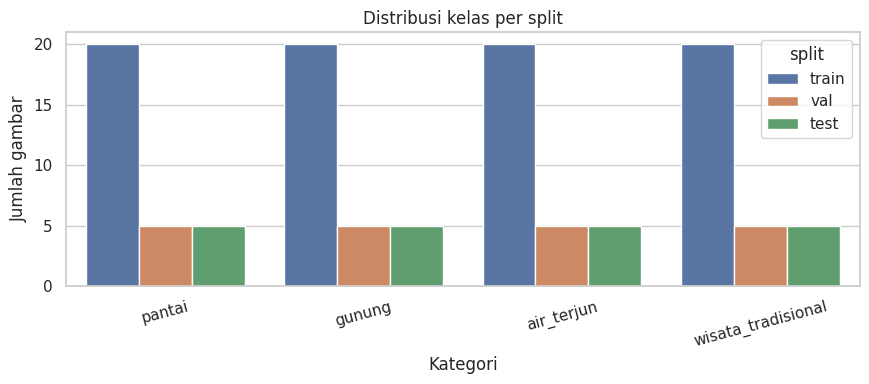

In [6]:
plt.figure(figsize=(9, 4))
sns.countplot(data=all_df, x="Classes", hue="split", order=CLASSES)
plt.title("Distribusi kelas per split")
plt.xlabel("Kategori")
plt.ylabel("Jumlah gambar")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [7]:
image_stats = []
for row in all_df.itertuples(index=False):
    with Image.open(row.image_path) as img:
        image_stats.append({
            "split": row.split,
            "class": row.Classes,
            "width": img.width,
            "height": img.height,
            "mode": img.mode,
        })

image_stats = pd.DataFrame(image_stats)
display(image_stats.describe(include="all"))
display(image_stats["mode"].value_counts().rename("image_mode_count"))

,split,class,width,height,mode
count,120,120,120.000000,120.000000,120
unique,3,4,NaN,NaN,2
top,train,pantai,NaN,NaN,RGB
freq,80,30,NaN,NaN,116
mean,NaN,NaN,863.650000,778.091667,NaN
std,NaN,NaN,157.384646,317.456514,NaN
min,NaN,NaN,413.000000,386.000000,NaN
25%,NaN,NaN,700.000000,606.750000,NaN
50%,NaN,NaN,960.000000,640.500000,NaN
75%,NaN,NaN,960.000000,720.000000,NaN


mode
RGB    116
L        4
Name: image_mode_count, dtype: int64

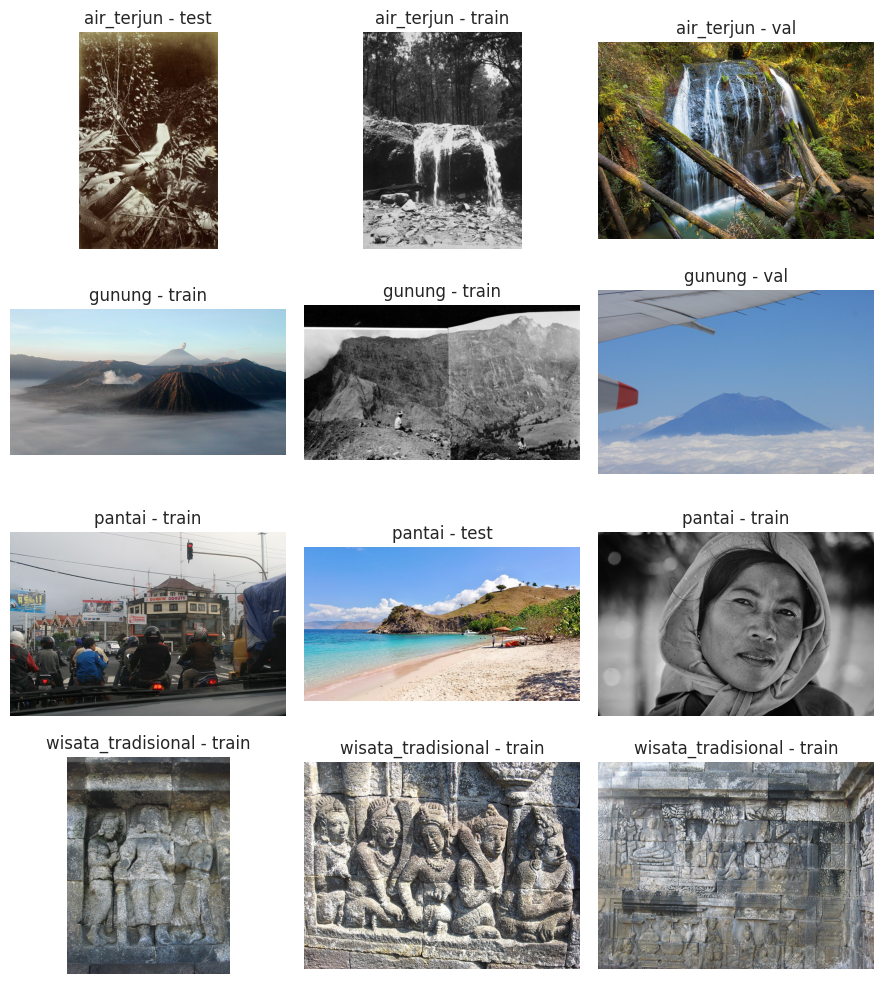

In [8]:
sample_df = all_df.groupby("Classes", group_keys=False).sample(3, random_state=SEED)

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 10))
for ax, row in zip(axes.flatten(), sample_df.itertuples(index=False)):
    with Image.open(row.image_path) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(f"{row.Classes} - {row.split}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Dataset dan Preprocessing

In [9]:
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.12, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class TourismImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row.image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = int(row.Labels)
        return image, label

train_ds = TourismImageDataset(train_df, train_tfms)
val_ds = TourismImageDataset(val_df, eval_tfms)
test_ds = TourismImageDataset(test_df, eval_tfms)

pin_memory = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

len(train_ds), len(val_ds), len(test_ds)

(80, 20, 20)

## Model

In [10]:
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(CLASSES))
model = model.to(device)

param_count = sum(p.numel() for p in model.parameters())
trainable_param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

{
    "model": MODEL_NAME,
    "params": param_count,
    "trainable_params": trainable_param_count,
    "classes": CLASSES,
}

{'model': 'mobilenetv4_conv_medium.e500_r224_in1k',
 'params': 8439636,
 'trainable_params': 8439636,
 'classes': ['pantai', 'gunung', 'air_terjun', 'wisata_tradisional']}

In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

def set_backbone_trainable(model, trainable):
    for param in model.parameters():
        param.requires_grad = trainable
    classifier = model.get_classifier()
    for param in classifier.parameters():
        param.requires_grad = True

def build_optimizer(model):
    params = [param for param in model.parameters() if param.requires_grad]
    return torch.optim.AdamW(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

set_backbone_trainable(model, trainable=False)
optimizer = build_optimizer(model)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, FREEZE_EPOCHS))


/tmp/ipykernel_5374/4023043037.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


## Training Loop

In [12]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    y_true, y_pred = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            y_true.extend(labels.detach().cpu().numpy().tolist())
            y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

In [13]:
best_val_f1 = -1.0
no_improve_count = 0
history = []
best_model_path = MODEL_DIR / "snaptrip_mobilenetv4_medium_best.pth"
last_model_path = MODEL_DIR / "snaptrip_mobilenetv4_medium_last.pth"

started_at = time.time()

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        set_backbone_trainable(model, trainable=True)
        optimizer = build_optimizer(model)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - FREEZE_EPOCHS))

    phase = "head" if epoch <= FREEZE_EPOCHS else "full"
    train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader)
    scheduler.step()

    row = {
        "epoch": epoch,
        "phase": phase,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    history.append(row)

    improved = val_metrics["macro_f1"] > best_val_f1 + MIN_DELTA
    if improved:
        best_val_f1 = val_metrics["macro_f1"]
        no_improve_count = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "model_name": MODEL_NAME,
            "classes": CLASSES,
            "label_to_class": LABEL_TO_CLASS,
            "class_to_label": CLASS_TO_LABEL,
            "img_size": IMG_SIZE,
            "epoch": epoch,
            "phase": phase,
            "val_macro_f1": best_val_f1,
            "preprocessing": {
                "resize": 256,
                "crop": IMG_SIZE,
                "mean": [0.485, 0.456, 0.406],
                "std": [0.229, 0.224, 0.225],
            },
        }, best_model_path)
    else:
        no_improve_count += 1

    print(
        f"Epoch {epoch:02d}/{EPOCHS} [{phase}] | "
        f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.3f} f1 {train_metrics['macro_f1']:.3f} | "
        f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.3f} f1 {val_metrics['macro_f1']:.3f} | "
        f"wait {no_improve_count}/{EARLY_STOPPING_PATIENCE}"
    )

    if epoch > FREEZE_EPOCHS and no_improve_count >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping aktif pada epoch {epoch}.")
        break

torch.save(model.state_dict(), last_model_path)

elapsed_minutes = (time.time() - started_at) / 60
history_df = pd.DataFrame(history)
history_df.to_csv(METRIC_DIR / "mobilenetv4_medium_training_history.csv", index=False)

elapsed_minutes, best_val_f1, str(best_model_path)



  0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_5374/3665888800.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):



 20%|██        | 1/5 [00:08<00:34,  8.67s/it]


  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_5374/3665888800.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):

 50%|█████     | 1/2 [00:00<00:00,  2.67it/s]

...


100%|██████████| 5/5 [00:01<00:00,  5.24it/s]


  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_5374/3665888800.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):

 50%|█████     | 1/2 [00:00<00:00,  2.39it/s]

Epoch 20/30 [full] | train loss 1.3673 acc 0.875 f1 0.876 | val loss 3.9916 acc 0.650 f1 0.636 | wait 7/7
Early stopping aktif pada epoch 20.


(1.2229703267415364,
 0.7373737373737373,
 '/home/rai/raidharma/output/model/snaptrip_mobilenetv4_medium_best.pth')

## Kurva Training

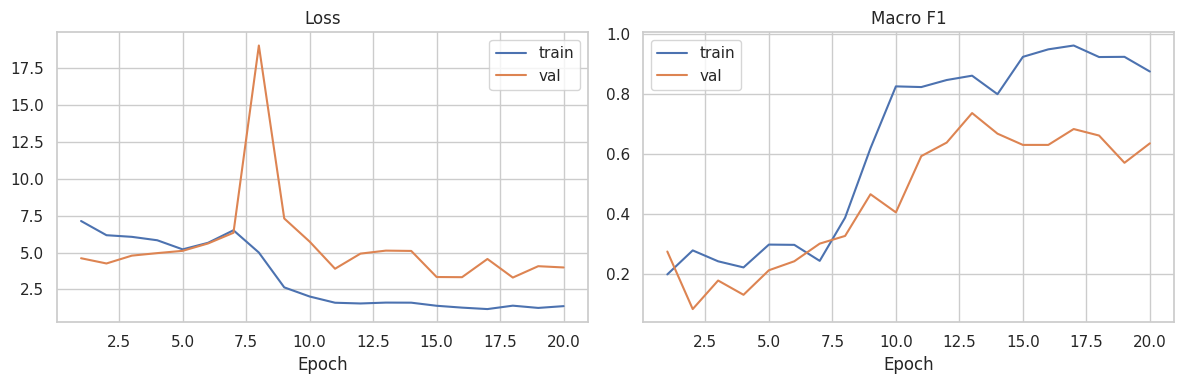

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_macro_f1"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="val")
axes[1].set_title("Macro F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(METRIC_DIR / "mobilenetv4_medium_training_curves.png", dpi=160)
plt.show()

## Evaluasi Test Set

In [15]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_probs = []
test_preds = []
test_true = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        test_probs.extend(probs.cpu().numpy().tolist())
        test_preds.extend(preds.cpu().numpy().tolist())
        test_true.extend(labels.numpy().tolist())

test_metrics = {
    "accuracy": accuracy_score(test_true, test_preds),
}
p, r, f1, _ = precision_recall_fscore_support(test_true, test_preds, average="macro", zero_division=0)
test_metrics.update({"macro_precision": p, "macro_recall": r, "macro_f1": f1})

test_metrics


  0%|          | 0/2 [00:00<?, ?it/s]


 50%|█████     | 1/2 [00:04<00:04,  4.16s/it]


100%|██████████| 2/2 [00:05<00:00,  2.24s/it]


100%|██████████| 2/2 [00:05<00:00,  2.55s/it]

{'accuracy': 0.35,
 'macro_precision': 0.3520833333333333,
 'macro_recall': 0.35,
 'macro_f1': 0.3389957264957265}

,precision,recall,f1-score,support
pantai,0.375000,0.60,0.461538,5.00
gunung,0.200000,0.20,0.200000,5.00
air_terjun,0.333333,0.20,0.250000,5.00
wisata_tradisional,0.500000,0.40,0.444444,5.00
accuracy,0.350000,0.35,0.350000,0.35
macro avg,0.352083,0.35,0.338996,20.00
weighted avg,0.352083,0.35,0.338996,20.00


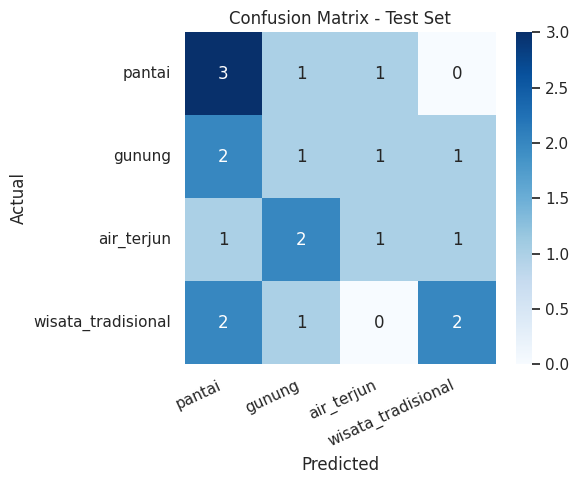

In [16]:
report = classification_report(test_true, test_preds, target_names=CLASSES, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df)

report_df.to_csv(METRIC_DIR / "mobilenetv4_medium_classification_report.csv")

cm = confusion_matrix(test_true, test_preds, labels=list(range(len(CLASSES))))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(METRIC_DIR / "mobilenetv4_medium_confusion_matrix.png", dpi=160)
plt.show()

In [17]:
pred_df = test_df[["filename", "Classes", "Labels", "image_path"]].copy()
pred_df["pred_label"] = test_preds
pred_df["pred_class"] = pred_df["pred_label"].map(LABEL_TO_CLASS)
pred_df["confidence"] = [float(max(prob)) for prob in test_probs]

for idx, class_name in LABEL_TO_CLASS.items():
    pred_df[f"prob_{class_name}"] = [float(prob[idx]) for prob in test_probs]

pred_df.to_csv(METRIC_DIR / "mobilenetv4_medium_test_predictions.csv", index=False)
pred_df

,filename,Classes,Labels,image_path,pred_label,pred_class,confidence,prob_pantai,prob_gunung,prob_air_terjun,prob_wisata_tradisional
0,0001.jpg,pantai,0,/home/rai/raidharma/data/test/0001.jpg,0,pantai,0.999641,9.996412e-01,9.486500e-08,9.077415e-11,3.587599e-04
1,0002.jpg,pantai,0,/home/rai/raidharma/data/test/0002.jpg,2,air_terjun,0.999777,3.191183e-06,1.536546e-07,9.997770e-01,2.196546e-04
2,0003.jpg,pantai,0,/home/rai/raidharma/data/test/0003.jpg,0,pantai,0.999997,9.999967e-01,5.042507e-07,1.006332e-07,2.700050e-06
3,0004.jpg,pantai,0,/home/rai/raidharma/data/test/0004.jpg,1,gunung,0.999993,5.396645e-10,9.999934e-01,2.632182e-10,6.590308e-06
4,0005.jpg,pantai,0,/home/rai/raidharma/data/test/0005.jpg,0,pantai,0.999982,9.999818e-01,2.916076e-08,1.691629e-05,1.236805e-06
5,0006.jpg,gunung,1,/home/rai/raidharma/data/test/0006.jpg,2,air_terjun,0.706276,2.936725e-01,4.646469e-05,7.062758e-01,5.215959e-06
6,0007.jpg,gunung,1,/home/rai/raidharma/data/test/0007.jpg,3,wisata_tradisional,0.788952,9.857150e-07,1.823555e-01,2.869152e-02,7.889520e-01
7,0008.jpg,gunung,1,/home/rai/raidharma/data/test/0008.jpg,0,pantai,0.999733,9.997332e-01,9.322412e-07,3.923059e-06,2.619384e-04
8,0009.jpg,gunung,1,/home/rai/raidharma/data/test/0009.jpg,1,gunung,0.999972,1.189263e-09,9.999722e-01,1.728551e-12,2.779960e-05
9,0010.jpg,gunung,1,/home/rai/raidharma/data/test/0010.jpg,0,pantai,1.000000,1.000000e+00,1.352062e-09,3.879234e-13,8.187884e-11


## Metadata Model

In [18]:
model_metadata = {
    "product": "SnapTrip",
    "framework": "pytorch",
    "architecture": "mobilenetv4_medium",
    "source_model": MODEL_NAME,
    "model_version": "2026-05-mvp-mobilenetv4-medium",
    "classes": CLASSES,
    "label_to_class": {str(k): v for k, v in LABEL_TO_CLASS.items()},
    "class_to_label": CLASS_TO_LABEL,
    "image_size": IMG_SIZE,
    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225],
    },
    "epochs_requested": EPOCHS,
    "epochs_ran": int(history_df["epoch"].max()),
    "freeze_epochs": FREEZE_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "best_val_macro_f1": float(best_val_f1),
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "output_contract": {
        "category_ids": CLASSES,
        "confidence_range": [0.0, 1.0],
    },
}

with open(MODEL_DIR / "snaptrip_mobilenetv4_medium_metadata.json", "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2)

model_metadata

{'product': 'SnapTrip',
 'framework': 'pytorch',
 'architecture': 'mobilenetv4_medium',
 'source_model': 'mobilenetv4_conv_medium.e500_r224_in1k',
 'model_version': '2026-05-mvp-mobilenetv4-medium',
 'classes': ['pantai', 'gunung', 'air_terjun', 'wisata_tradisional'],
 'label_to_class': {'0': 'pantai',
  '1': 'gunung',
  '2': 'air_terjun',
  '3': 'wisata_tradisional'},
 'class_to_label': {'pantai': 0,
  'gunung': 1,
  'air_terjun': 2,
  'wisata_tradisional': 3},
 'image_size': 224,
 'normalization': {'mean': [0.485, 0.456, 0.406],
  'std': [0.229, 0.224, 0.225]},
 'epochs_requested': 30,
 'epochs_ran': 20,
 'freeze_epochs': 5,
 'early_stopping_patience': 7,
 'best_val_macro_f1': 0.7373737373737373,
 'test_metrics': {'accuracy': 0.35,
  'macro_precision': 0.3520833333333333,
  'macro_recall': 0.35,
  'macro_f1': 0.3389957264957265},
 'output_contract': {'category_ids': ['pantai',
   'gunung',
   'air_terjun',
   'wisata_tradisional'],
  'confidence_range': [0.0, 1.0]}}

## Inferences

In [19]:
def predict_image(image_path, top_k=4):
    image = Image.open(image_path).convert("RGB")
    tensor = eval_tfms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze(0).cpu().numpy()

    order = probs.argsort()[::-1][:top_k]
    return [
        {"category": LABEL_TO_CLASS[int(idx)], "confidence": float(probs[idx])}
        for idx in order
    ]

predict_image(test_df.iloc[0].image_path)

[{'category': 'pantai', 'confidence': 0.9996412992477417},
 {'category': 'wisata_tradisional', 'confidence': 0.0003585522645153105},
 {'category': 'gunung', 'confidence': 9.530536004831447e-08},
 {'category': 'air_terjun', 'confidence': 9.270339357270174e-11}]